# Tahap 2 � Full Fine-Tuning IndoBERT untuk Emotion Classification
Tujuan dari notebook ini adalah melakukan full fine-tuning model IndoBERT pada dataset PRDECT-ID. Seluruh parameter model akan di-update (trainable) untuk mendapatkan representasi emosi yang optimal. Hasil eksperimen mencakup metrik evaluasi, visualisasi, dan analisis kesalahan (error analysis).

## 1. Configuration & Setup
Mendefinisikan parameter eksperimen dan mengatur seed untuk reproducibility.

In [3]:
import os
import random
import json
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from datetime import datetime

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# --- Reproducibility ---
RANDOM_STATE = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)

# --- Hyperparameters ---
MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
NUM_LABELS = 5

# --- Path Configuration ---
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/xai_lime_vs_shap"
else:
    print("Running locally.")
    BASE_PATH = ".."

TRAIN_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_train.csv"
TEST_DATA_PATH = f"{BASE_PATH}/data/processed/prdect_test.csv"
MAPPING_PATH = f"{BASE_PATH}/data/processed/prdect_label_mapping.json"
OUTPUT_DIR = f"{BASE_PATH}/outputs/finetuning_indobert"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/model", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/plots", exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device used: {DEVICE}")

ModuleNotFoundError: No module named 'pandas'

## 2. Load Processed Dataset

In [2]:
df_train = pd.read_csv(TRAIN_DATA_PATH)
df_test = pd.read_csv(TEST_DATA_PATH)

with open(MAPPING_PATH, 'r') as f:
    label_mapping = json.load(f)

print(f"Train samples: {len(df_train)}")
print(f"Test samples : {len(df_test)}")
print("-" * 30)
print("Label Mapping:")
print(label_mapping)

# Sample Preview
df_train[['Customer Review', 'Emotion']].head()

Train samples: 4264
Test samples : 1066
------------------------------
Label Mapping:
{'Anger': 0, 'Fear': 1, 'Happy': 2, 'Love': 3, 'Sadness': 4}


,Customer Review,Emotion
0,barang belum sampai sampai hari ini toko pefia...,Fear
1,barang sangat jelek tidak fungsi klaim tetap r...,Anger
2,produk bagus proses sangat cepat penjual ramah...,Love
3,seller ramah dan fast response packaging rapih...,Love
4,packing tebel double bubble wrap kardus di dlm...,Fear


## 3. Tokenization
Menggunakan tokenizer IndoBERT untuk memproses teks menjadi format yang dimengerti model.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Original Text: barang belum sampai sampai hari ini toko pefia tolong reviwe lagi kerjasama dengan kurir antaraja itu sangat lelet dan gak bertanggung jawab barang belum sampai sdh di konfirmasi diterima pemesan hadeeehhh kurir abal2 lama super lelet
Tokens       : ['barang', 'belum', 'sampai', 'sampai', 'hari', 'ini', 'toko', 'pe', '##fi', '##a', 'tolong', 'rev', '##i', '##we', 'lagi', 'kerjasama', 'dengan', 'kurir', 'antara', '##ja', 'itu', 'sangat', 'lele', '##t', 'dan', 'gak', 'bertanggung', 'jawab', 'barang', 'belum', 'sampai', 'sdh', 'di', 'konfirmasi', 'diterima', 'pemesan', 'had', '##eee', '##hhh', 'kurir', 'abal', '##2', 'lama', 'super', 'lele', '##t']
Token IDs    : [963, 659, 493, 493, 406, 92, 1605, 1094, 3319, 30354, 3854, 3913, 30356, 7801, 423, 4517, 79, 12065, 644, 255, 137, 310, 9214, 30358, 41, 1489, 3987, 1024, 963, 659, 493, 8055, 26, 7894, 2993, 24162, 1165, 14243, 12126, 12065, 23365, 30378, 985, 2721, 9214, 30358]


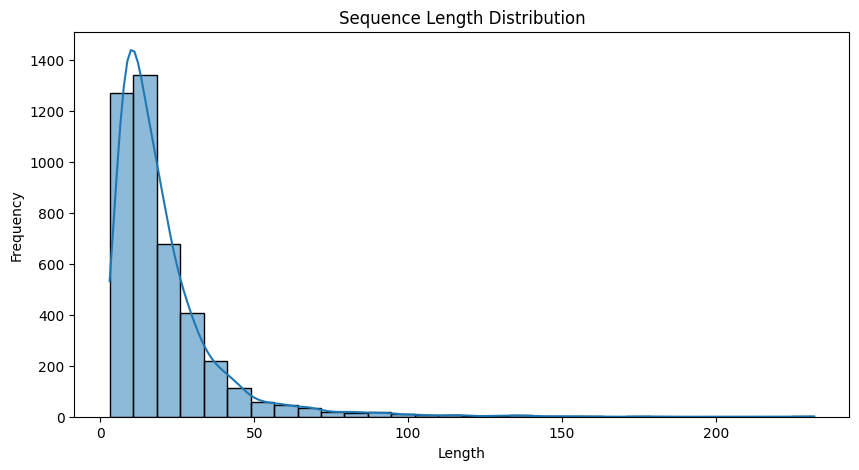

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Test Tokenization
sample_text = df_train['Customer Review'].iloc[0]
tokens = tokenizer.tokenize(sample_text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {sample_text}")
print(f"Tokens       : {tokens}")
print(f"Token IDs    : {token_ids}")

# Visualize Sequence Length Distribution
lengths = df_train['Customer Review'].apply(lambda x: len(tokenizer.encode(x)))
plt.figure(figsize=(10, 5))
sns.histplot(lengths, bins=30, kde=True)
plt.title("Sequence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

## 4. Dataset & DataLoader

In [4]:
class EmotionDataset(Dataset):
    def __init__(self, reviews, labels, tokenizer, max_len):
        self.reviews = reviews
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.reviews)
    
    def __getitem__(self, item):
        review = str(self.reviews[item])
        label = self.labels[item]
        
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        
        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(df, tokenizer, max_len, batch_size, shuffle=True):
    ds = EmotionDataset(
        reviews=df['Customer Review'].to_numpy(),
        labels=df['Label'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE, shuffle=False)

## 5. Full Fine-Tuning IndoBERT Initialization
Memuat pre-trained model dan memastikan seluruh parameter bersifat trainable.

In [5]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME, 
    num_labels=NUM_LABELS
)
model = model.to(DEVICE)

# Verify all parameters are trainable (Full Fine-Tuning)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# Example check
for name, param in model.named_parameters():
    if not param.requires_grad:
        print(f"WARNING: Parameter {name} is not trainable!")

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Parameters    : 124,445,189
Trainable Parameters: 124,445,189


## 6. Training Configuration & Loop

In [6]:
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_data_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)
loss_fn = nn.CrossEntropyLoss().to(DEVICE)

def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    
    progress_bar = tqdm(data_loader, desc="Training")
    for d in progress_bar:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        logits = outputs.logits
        _, preds = torch.max(logits, dim=1)
        loss = loss_fn(logits, labels)
        
        correct_predictions += torch.sum(preds == labels)
        losses.append(loss.item())
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        progress_bar.set_postfix({'loss': np.mean(losses)})
        
    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["labels"].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            loss = loss_fn(logits, labels)
            
            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())
            
    return correct_predictions.double() / n_examples, np.mean(losses)

## 7. Execution: Training Loop

In [7]:
history = {
    'train_acc': [], 'train_loss': [],
    'val_acc': [], 'val_loss': []
}
best_accuracy = 0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print('-' * 10)
    
    train_acc, train_loss = train_epoch(
        model, train_data_loader, loss_fn, optimizer, DEVICE, scheduler, len(df_train)
    )
    print(f'Train loss {train_loss:.4f} accuracy {train_acc:.4f}')
    
    val_acc, val_loss = eval_model(
        model, test_data_loader, loss_fn, DEVICE, len(df_test)
    )
    print(f'Val   loss {val_loss:.4f} accuracy {val_acc:.4f}')
    print()
    
    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)
    
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), f'{OUTPUT_DIR}/model/best_model_state.bin')
        best_accuracy = val_acc

end_time = time.time()
duration = end_time - start_time
print(f"Training completed in: {duration/60:.2f} minutes")

Epoch 1/5
----------


Training:   0%|          | 0/267 [00:00<?, ?it/s]

AttributeError: BertTokenizer has no attribute encode_plus

## 8. Evaluation & Visualization

In [ ]:
# Plotting Training Curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='train loss')
plt.plot(history['val_loss'], label='validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/plots/training_curves.png")
plt.show()

# Final Evaluation on Test Set
def get_predictions(model, data_loader):
    model = model.eval()
    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []
    
    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(DEVICE)
            attention_mask = d["attention_mask"].to(DEVICE)
            labels = d["labels"].to(DEVICE)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=1)
            _, preds = torch.max(logits, dim=1)
            
            review_texts.extend(texts)
            predictions.extend(preds)
            prediction_probs.extend(probs)
            real_values.extend(labels)
            
    predictions = torch.stack(predictions).cpu()
    prediction_probs = torch.stack(prediction_probs).cpu()
    real_values = torch.stack(real_values).cpu()
    return review_texts, predictions, prediction_probs, real_values

y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(model, test_data_loader)

# Classification Report
class_names = list(label_mapping.keys())
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
plt.figure(figsize=(10, 7))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"{OUTPUT_DIR}/plots/confusion_matrix.png")
plt.show()

## 9. Error Analysis
Menganalisis sampel yang diprediksi salah untuk memahami pola misklasifikasi model.

In [ ]:
error_df = pd.DataFrame({
    'review_text': y_review_texts,
    'true_labels': y_test,
    'pred_labels': y_pred,
    'confidence': [probs[pred].item() for probs, pred in zip(y_pred_probs, y_pred)]
})

# Filter only errors
errors = error_df[error_df['true_labels'] != error_df['pred_labels']].copy()

# Map back to names
inv_mapping = {v: k for k, v in label_mapping.items()}
errors['true_emotion'] = errors['true_labels'].map(inv_mapping)
errors['pred_emotion'] = errors['pred_labels'].map(inv_mapping)

# Show Top 10 High-Confidence Errors
print("Top 10 High-Confidence Errors:")
display(errors.sort_values(by='confidence', ascending=False).head(10))

# Misclassification Pattern
error_pattern = errors.groupby(['true_emotion', 'pred_emotion']).size().reset_index(name='count')
error_pattern = error_pattern.sort_values(by='count', ascending=False)
print("\nTop Misclassification Patterns:")
display(error_pattern.head(10))

# Save Error Report
errors.to_csv(f"{OUTPUT_DIR}/reports/error_analysis.csv", index=False)

## 10. Save Model & Tokenizer

In [ ]:
# Save Final Model and Tokenizer
model.save_pretrained(f"{OUTPUT_DIR}/model/final_indobert_emotion")
tokenizer.save_pretrained(f"{OUTPUT_DIR}/tokenizer/indobert_tokenizer")

# Save Training History
with open(f"{OUTPUT_DIR}/reports/training_history.json", "w") as f:
    json.dump(history, f)

print(f"All assets saved to: {OUTPUT_DIR}")

## 11. Experiment Summary

In [ ]:
total_dataset = len(df_train) + len(df_test)
final_accuracy = accuracy_score(y_test, y_pred)
final_f1_macro = f1_score(y_test, y_pred, average='macro')

print("=== FINAL EXPERIMENT SUMMARY ===")
print(f"Model Name           : {MODEL_NAME}")
print(f"Total Dataset        : {total_dataset}")
print(f"Train / Test Size    : {len(df_train)} / {len(df_test)}")
print(f"Epochs               : {EPOCHS}")
print(f"Learning Rate        : {LEARNING_RATE}")
print(f"Final Test Accuracy  : {final_accuracy:.4f}")
print(f"Final Test F1 (Macro): {final_f1_macro:.4f}")
print(f"Training Duration    : {duration/60:.2f} minutes")
print(f"Random State         : {RANDOM_STATE}")
print(f"Timestamp            : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")